# Linear Regression From Scratch Using NumPy

In this notebook, we build a **Linear Regression model completely from scratch** — no scikit-learn, no black boxes. We use only NumPy for math and Matplotlib for visualization.

By the end of this notebook, you will understand:
- What linear regression is and how it works mathematically
- What a cost function (Mean Squared Error) is
- How gradient descent optimizes the model
- How to evaluate model performance

---

## Table of Contents

1. [What is Linear Regression?](#1)
2. [Generating Synthetic Data](#2)
3. [Visualizing the Data](#3)
4. [The Math Behind Linear Regression](#4)
5. [Implementing the Model Class](#5)
6. [Training the Model](#6)
7. [Visualizing the Training Process](#7)
8. [Making Predictions](#8)
9. [Evaluating the Model](#9)
10. [Comparing With the Analytical Solution](#10)
11. [Summary](#11)

---

## 1. What is Linear Regression?

Linear regression is one of the most fundamental algorithms in machine learning. It models the **relationship between an input variable X and a continuous output variable y** by fitting a straight line.

The equation of the line is:

$$\hat{y} = wX + b$$

Where:
- $\hat{y}$ is the predicted value
- $X$ is the input feature
- $w$ is the **weight** (slope of the line)
- $b$ is the **bias** (y-intercept)

Our goal is to find the values of $w$ and $b$ that make predictions as accurate as possible.

---

## 2. Generating Synthetic Data

We will create a synthetic dataset where we **already know the true relationship** between X and y. This is useful because we can later verify if our model learned the correct parameters.

We simulate house sizes (in square feet) and their prices (in thousands of dollars), using:

$$y = 3.5 \cdot X + 50 + \text{noise}$$

So the true weight is **3.5** and the true bias is **50**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# --- Synthetic Data Parameters ---
TRUE_WEIGHT = 3.5      # true slope
TRUE_BIAS   = 50.0     # true intercept
N_SAMPLES   = 200      # number of data points
NOISE_STD   = 20.0     # standard deviation of Gaussian noise

# Generate input: house sizes between 500 and 3000 sq ft
X = np.random.uniform(500, 3000, size=N_SAMPLES)

# Generate output: price = 3.5 * size + 50 + noise
noise = np.random.normal(0, NOISE_STD, size=N_SAMPLES)
y = TRUE_WEIGHT * X + TRUE_BIAS + noise

print(f"Dataset shape  : X={X.shape}, y={y.shape}")
print(f"X range        : [{X.min():.1f}, {X.max():.1f}]")
print(f"y range        : [{y.min():.1f}, {y.max():.1f}]")
print(f"True weight (w): {TRUE_WEIGHT}")
print(f"True bias   (b): {TRUE_BIAS}")

Matplotlib is building the font cache; this may take a moment.


Dataset shape  : X=(200,), y=(200,)
X range        : [513.8, 2967.2]
y range        : [1838.9, 10450.0]
True weight (w): 3.5
True bias   (b): 50.0


---

## 3. Visualizing the Data

Before building any model, always **look at your data**. A scatter plot helps us confirm there is a linear relationship between house size and price.

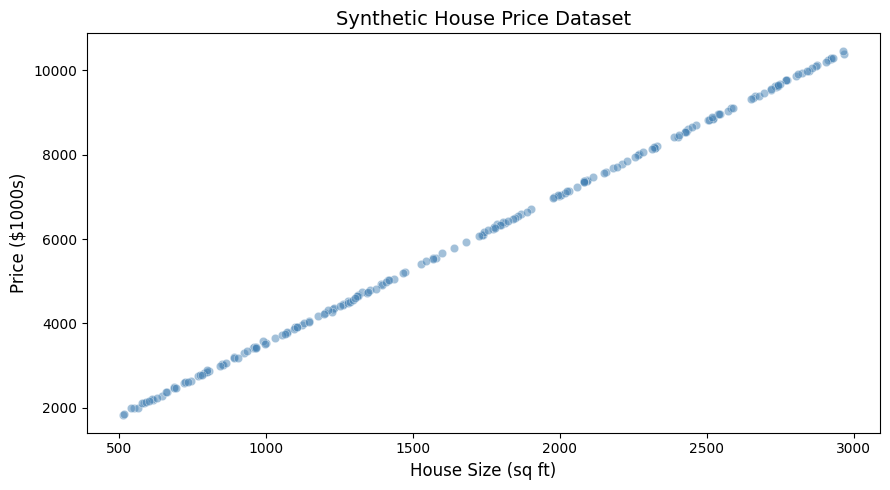

In [2]:
plt.figure(figsize=(9, 5))
plt.scatter(X, y, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.4)
plt.xlabel("House Size (sq ft)", fontsize=12)
plt.ylabel("Price ($1000s)", fontsize=12)
plt.title("Synthetic House Price Dataset", fontsize=14)
plt.tight_layout()
plt.show()

---

## 4. The Math Behind Linear Regression

### 4.1 Cost Function — Mean Squared Error (MSE)

To measure how wrong our predictions are, we use **Mean Squared Error**:

$$J(w, b) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

Where $N$ is the number of training examples. The lower the MSE, the better the model.

### 4.2 Gradient Descent

We minimize $J(w, b)$ using **gradient descent** — an iterative algorithm that nudges $w$ and $b$ in the direction that reduces the cost.

The update rules at each step are:

$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

Where $\alpha$ is the **learning rate** — a small positive number that controls step size.

### 4.3 Computing the Gradients

Taking partial derivatives of MSE:

$$\frac{\partial J}{\partial w} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) \cdot X_i$$

$$\frac{\partial J}{\partial b} = \frac{2}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

The factor of 2 cancels out in practice (absorbed into the learning rate), so we often write $\frac{1}{N}$ instead.

---

## 5. Implementing the Model Class

We implement `LinearRegression` as a Python class with three methods:
- `fit(X, y)` — trains the model using gradient descent
- `predict(X)` — returns predictions for new data
- `score(X, y)` — returns the R² score

In [3]:
class LinearRegressionNumPy:
    """
    Simple linear regression (single feature) trained with gradient descent.

    Parameters
    ----------
    learning_rate : float
        Step size for each gradient descent update.
    n_iterations : int
        Number of passes through the training data.
    """

    def __init__(self, learning_rate=1e-6, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations  = n_iterations
        self.weight        = 0.0   # w: initialized to zero
        self.bias          = 0.0   # b: initialized to zero
        self.cost_history  = []    # track MSE at each iteration

    # ------------------------------------------------------------------
    # FORWARD PASS: compute predictions
    # ------------------------------------------------------------------
    def predict(self, X):
        """Return predicted values: y_hat = w*X + b"""
        return self.weight * X + self.bias

    # ------------------------------------------------------------------
    # COST FUNCTION: Mean Squared Error
    # ------------------------------------------------------------------
    def _compute_cost(self, y_hat, y):
        """MSE = (1/N) * sum((y_hat - y)^2)"""
        N = len(y)
        return (1 / N) * np.sum((y_hat - y) ** 2)

    # ------------------------------------------------------------------
    # GRADIENTS: partial derivatives of MSE w.r.t. w and b
    # ------------------------------------------------------------------
    def _compute_gradients(self, X, y, y_hat):
        """
        dJ/dw = (1/N) * sum((y_hat - y) * X)
        dJ/db = (1/N) * sum(y_hat - y)
        """
        N      = len(y)
        error  = y_hat - y             # residuals: shape (N,)
        dw     = (1 / N) * np.dot(error, X)   # scalar
        db     = (1 / N) * np.sum(error)       # scalar
        return dw, db

    # ------------------------------------------------------------------
    # TRAINING LOOP: gradient descent
    # ------------------------------------------------------------------
    def fit(self, X, y, verbose=True):
        """
        Train the model on data (X, y).

        Parameters
        ----------
        X : np.ndarray, shape (N,)
        y : np.ndarray, shape (N,)
        verbose : bool — print cost every 100 iterations
        """
        self.cost_history = []

        for i in range(self.n_iterations):

            # Step 1: Forward pass
            y_hat = self.predict(X)

            # Step 2: Compute cost
            cost = self._compute_cost(y_hat, y)
            self.cost_history.append(cost)

            # Step 3: Compute gradients
            dw, db = self._compute_gradients(X, y, y_hat)

            # Step 4: Update parameters
            self.weight -= self.learning_rate * dw
            self.bias   -= self.learning_rate * db

            # Optional: print progress
            if verbose and (i % 200 == 0 or i == self.n_iterations - 1):
                print(f"Iter {i:>5d} | Cost: {cost:>12.4f} | "
                      f"w: {self.weight:.4f} | b: {self.bias:.4f}")

        return self

    # ------------------------------------------------------------------
    # EVALUATION: R-squared score
    # ------------------------------------------------------------------
    def score(self, X, y):
        """
        R² = 1 - SS_res / SS_tot

        R² = 1.0  ->  perfect predictions
        R² = 0.0  ->  model predicts the mean (no better than a flat line)
        R² < 0.0  ->  model is worse than predicting the mean
        """
        y_hat  = self.predict(X)
        ss_res = np.sum((y - y_hat) ** 2)        # residual sum of squares
        ss_tot = np.sum((y - np.mean(y)) ** 2)   # total sum of squares
        return 1 - (ss_res / ss_tot)


print("LinearRegressionNumPy class defined successfully.")

LinearRegressionNumPy class defined successfully.


---

## 6. Training the Model

### 6.1 Train / Test Split

We split the data into 80% training and 20% testing. The model learns only from training data; the test set is used to evaluate how well it generalizes.

In [4]:
# Shuffle indices
indices = np.random.permutation(N_SAMPLES)
split   = int(0.8 * N_SAMPLES)

train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 160
Testing  samples : 40


### 6.2 Feature Normalization

Gradient descent converges much faster when input features are on a similar scale. We apply **Min-Max normalization** to bring X into the range [0, 1]:

$$X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$

> **Important:** We compute min and max from the *training set only*, then apply the same transformation to the test set. This prevents **data leakage**.

In [5]:
X_min = X_train.min()
X_max = X_train.max()

X_train_norm = (X_train - X_min) / (X_max - X_min)
X_test_norm  = (X_test  - X_min) / (X_max - X_min)

print(f"X_train_norm range: [{X_train_norm.min():.4f}, {X_train_norm.max():.4f}]")
print(f"X_test_norm  range: [{X_test_norm.min():.4f},  {X_test_norm.max():.4f}]")

X_train_norm range: [0.0000, 1.0000]
X_test_norm  range: [0.0320,  0.9751]


### 6.3 Fit the Model

In [6]:
model = LinearRegressionNumPy(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_norm, y_train)

print("\n--- Learned Parameters ---")
print(f"Weight (w) : {model.weight:.4f}")
print(f"Bias   (b) : {model.bias:.4f}")

Iter     0 | Cost: 43307027.8982 | w: 374.4336 | b: 603.1554
Iter   200 | Cost:  168676.2718 | w: 7267.5026 | b: 2544.0614
Iter   400 | Cost:    8719.3799 | w: 8291.4368 | b: 2005.0691
Iter   600 | Cost:     785.0826 | w: 8519.4840 | b: 1885.0265
Iter   800 | Cost:     391.5199 | w: 8570.2739 | b: 1858.2910
Iter   999 | Cost:     372.0135 | w: 8581.5613 | b: 1852.3494

--- Learned Parameters ---
Weight (w) : 8581.5613
Bias   (b) : 1852.3494


---

## 7. Visualizing the Training Process

### 7.1 Cost Curve (Learning Curve)

The cost should decrease and eventually flatten, showing the model has converged. If it does not decrease, the learning rate may be too large.

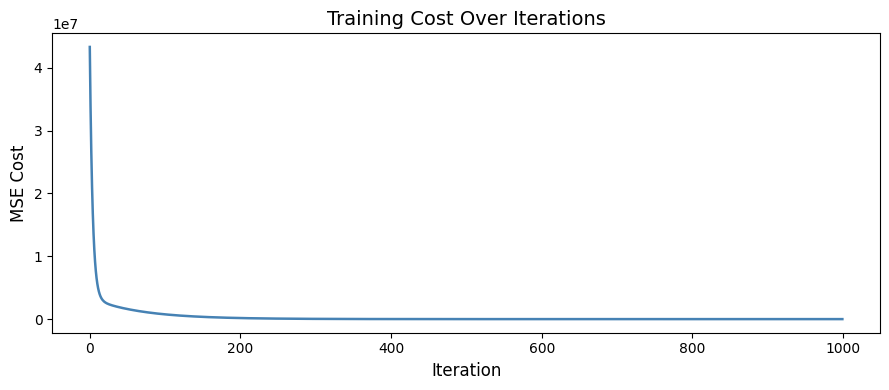

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(model.cost_history, color='steelblue', linewidth=1.8)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.title("Training Cost Over Iterations", fontsize=14)
plt.tight_layout()
plt.show()

### 7.2 Fitted Line on Training Data

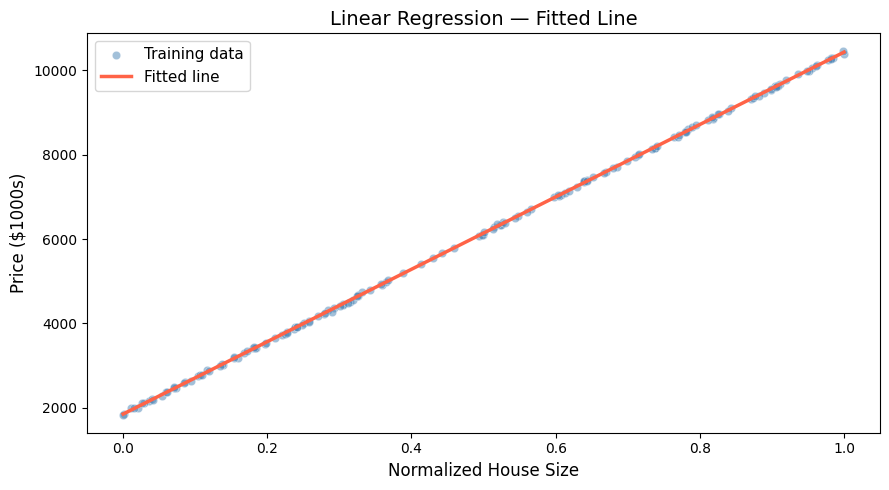

In [8]:
# Create a line across the full normalized range
x_line      = np.linspace(0, 1, 200)
y_line_pred = model.predict(x_line)

plt.figure(figsize=(9, 5))
plt.scatter(X_train_norm, y_train, alpha=0.5, color='steelblue',
            edgecolors='white', linewidths=0.4, label='Training data')
plt.plot(x_line, y_line_pred, color='tomato', linewidth=2.5, label='Fitted line')
plt.xlabel("Normalized House Size", fontsize=12)
plt.ylabel("Price ($1000s)", fontsize=12)
plt.title("Linear Regression — Fitted Line", fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

## 8. Making Predictions

We use the trained model to predict house prices on the **test set**, which the model has never seen during training.

In [9]:
y_pred = model.predict(X_test_norm)

# Show first 10 predictions vs actual
print(f"{'Actual':>12}  {'Predicted':>12}  {'Error':>10}")
print("-" * 38)
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    error = actual - predicted
    print(f"{actual:>12.2f}  {predicted:>12.2f}  {error:>10.2f}")

      Actual     Predicted       Error
--------------------------------------
     6590.87       6584.78        6.09
     6982.22       6971.13       11.08
     2128.91       2126.62        2.29
     4331.94       4350.72      -18.78
     7149.95       7134.41       15.54
     6488.45       6489.15       -0.70
     3435.10       3435.53       -0.42
     2818.18       2817.28        0.90
     2233.86       2254.22      -20.36
     4528.64       4529.82       -1.19


---

## 9. Evaluating the Model

### 9.1 Metrics

We evaluate using three standard regression metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{N}\sum(\hat{y}-y)^2$ | Average squared error (penalizes large errors) |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same units as target variable |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained (closer to 1 is better) |

In [10]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

mse  = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = model.score(X_test_norm, y_test)

print("--- Test Set Evaluation ---")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  (in $1000s)")
print(f"R²   : {r2:.4f}")

--- Test Set Evaluation ---
MSE  : 386.3311
RMSE : 19.6553  (in $1000s)
R²   : 0.9999


### 9.2 Residuals Plot

Residuals are the difference between actual and predicted values: $e_i = y_i - \hat{y}_i$.

For a well-fitted linear model, residuals should:
- Be randomly scattered around zero
- Show no obvious pattern

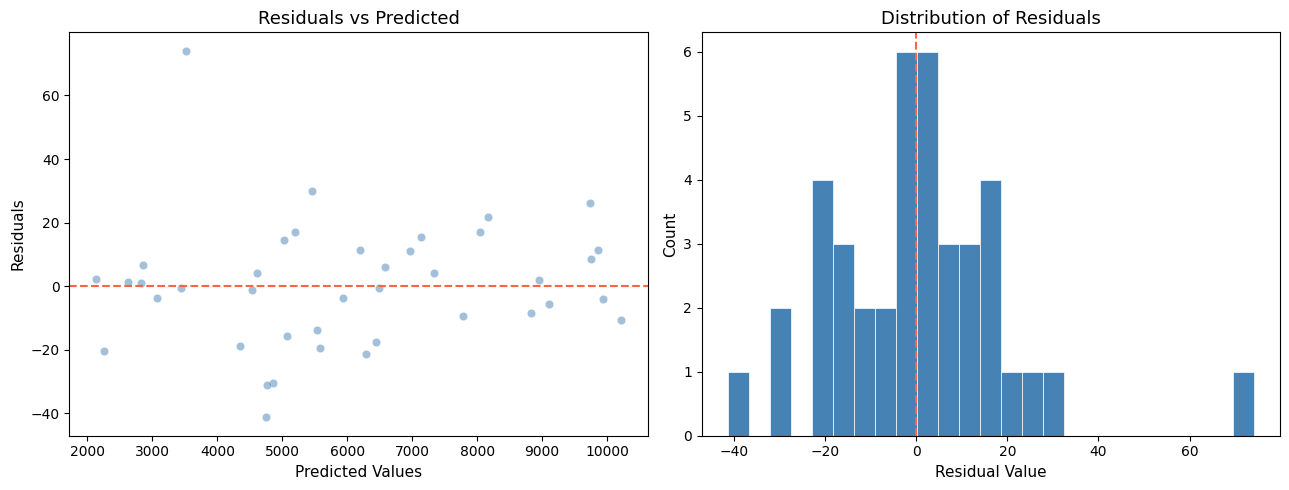

In [11]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5, color='steelblue',
                edgecolors='white', linewidths=0.4)
axes[0].axhline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[0].set_xlabel("Predicted Values", fontsize=11)
axes[0].set_ylabel("Residuals", fontsize=11)
axes[0].set_title("Residuals vs Predicted", fontsize=13)

# Histogram of residuals
axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Residual Value", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Distribution of Residuals", fontsize=13)

plt.tight_layout()
plt.show()

### 9.3 Actual vs Predicted Plot

Points close to the diagonal line $y = \hat{y}$ indicate accurate predictions.

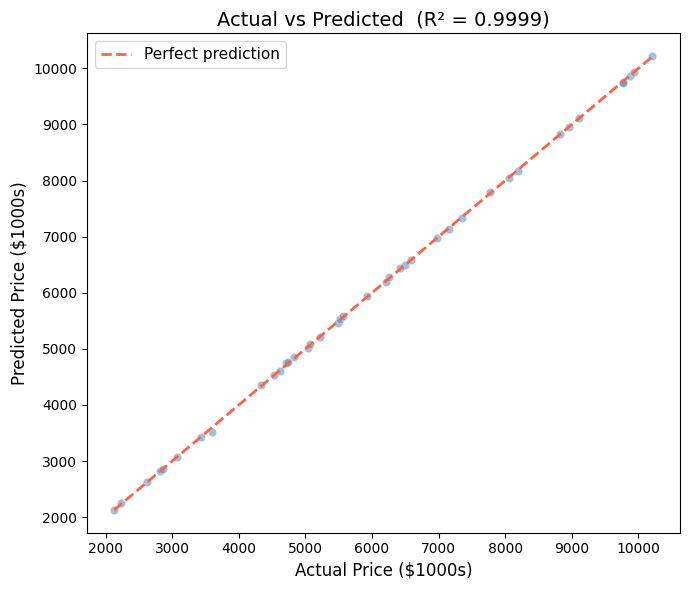

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue',
            edgecolors='white', linewidths=0.4)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='tomato', linewidth=2, linestyle='--', label='Perfect prediction')

plt.xlabel("Actual Price ($1000s)", fontsize=12)
plt.ylabel("Predicted Price ($1000s)", fontsize=12)
plt.title(f"Actual vs Predicted  (R² = {r2:.4f})", fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---

## 10. Comparing With the Analytical Solution

Linear regression has an **exact closed-form solution** called the **Normal Equation**:

$$w = \frac{\sum (X_i - \bar{X})(y_i - \bar{y})}{\sum (X_i - \bar{X})^2}, \quad b = \bar{y} - w \cdot \bar{X}$$

This solves the problem directly in one step without iteration. We use it as a sanity check.

In [13]:
# --- Analytical / Normal Equation Solution ---
X_mean = X_train_norm.mean()
y_mean = y_train.mean()

w_analytical = np.sum((X_train_norm - X_mean) * (y_train - y_mean)) / \
               np.sum((X_train_norm - X_mean) ** 2)
b_analytical = y_mean - w_analytical * X_mean

# --- Comparison ---
print("Parameter comparison")
print(f"{'':20} {'Gradient Descent':>18} {'Normal Equation':>16}")
print("-" * 56)
print(f"{'Weight (w)':20} {model.weight:>18.4f} {w_analytical:>16.4f}")
print(f"{'Bias   (b)':20} {model.bias:>18.4f} {b_analytical:>16.4f}")

# R² for analytical solution
y_pred_analytical = w_analytical * X_test_norm + b_analytical
ss_res_a = np.sum((y_test - y_pred_analytical) ** 2)
ss_tot   = np.sum((y_test - y_test.mean()) ** 2)
r2_analytical = 1 - ss_res_a / ss_tot

print()
print(f"R² (Gradient Descent) : {r2:.6f}")
print(f"R² (Normal Equation)  : {r2_analytical:.6f}")

Parameter comparison
                       Gradient Descent  Normal Equation
--------------------------------------------------------
Weight (w)                    8581.5613        8584.8269
Bias   (b)                    1852.3494        1850.6304

R² (Gradient Descent) : 0.999929
R² (Normal Equation)  : 0.999929


Both methods should yield nearly identical results. The normal equation is exact; gradient descent is an approximation that gets very close with enough iterations.

> **When to use which?**
> - **Normal Equation**: Fast and exact, but computationally expensive for very large datasets (scales as $O(n^3)$).
> - **Gradient Descent**: Scales much better to large datasets and generalizes to other models (neural networks, etc.).